In [1]:
import pandas as pd

# Column names for the NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty'
]

# Load the datasets
train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
# See all unique attack types in the dataset
print("Unique attack types:")
print(train_df['attack_type'].value_counts())

Unique attack types:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [3]:
# Drop the 'difficulty' column - it's not a real network feature
train_df = train_df.drop(columns=['difficulty'])
test_df = test_df.drop(columns=['difficulty'])

# Create binary label: 0 = normal, 1 = attack
train_df['label'] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

print("Training label distribution:")
print(train_df['label'].value_counts())

Training label distribution:
label
0    67343
1    58630
Name: count, dtype: int64


In [4]:
# Check for missing values
print("Missing values in training set:")
print(train_df.isnull().sum().sum())

print("\nMissing values in test set:")
print(test_df.isnull().sum().sum())

# Check data types
print("\nData types:")
print(train_df.dtypes.value_counts())

Missing values in training set:
0

Missing values in test set:
0

Data types:
int64      24
float64    15
object      4
Name: count, dtype: int64


In [5]:
# Find the categorical columns
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['protocol_type', 'service', 'flag', 'attack_type']


In [6]:
# See unique values in each categorical column
for col in ['protocol_type', 'service', 'flag']:
    print(f"{col}: {train_df[col].nunique()} unique values")
    print(train_df[col].unique())
    print()

protocol_type: 3 unique values
['tcp' 'udp' 'icmp']

service: 70 unique values
['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

flag: 11 unique values
['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']



C:\Users\riyan\AppData\Local\Temp\ipykernel_17128\3259171689.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='Set2')


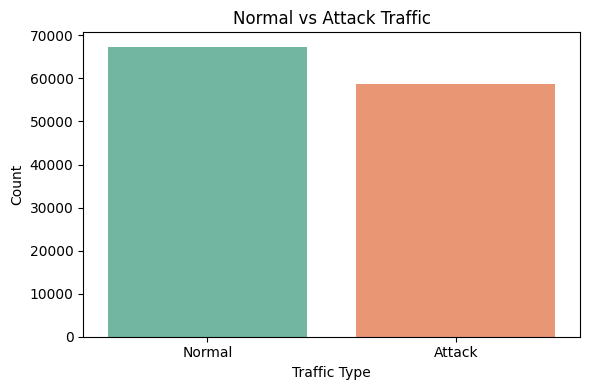

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Attack vs Normal distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=train_df, palette='Set2')
plt.title('Normal vs Attack Traffic')
plt.xticks([0, 1], ['Normal', 'Attack'])
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

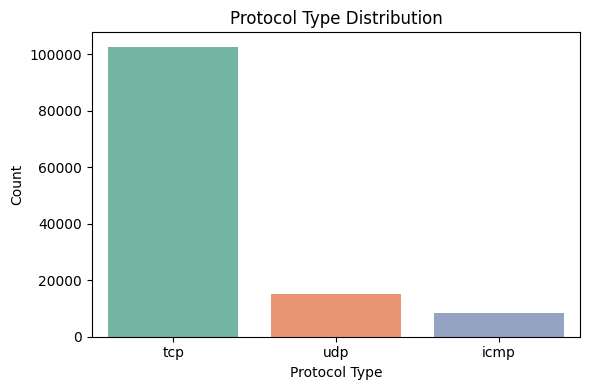

In [8]:
# Plot 2: Protocol type distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='protocol_type', hue='protocol_type', data=train_df, palette='Set2', legend=False)
plt.title('Protocol Type Distribution')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


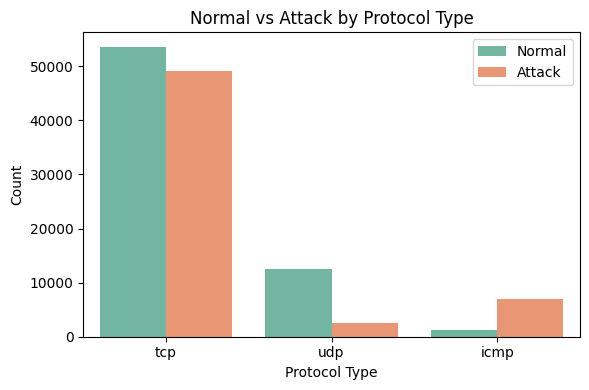

In [9]:
# Plot 3: Attack type by protocol
plt.figure(figsize=(6, 4))
sns.countplot(x='protocol_type', hue='label', data=train_df, palette='Set2')
plt.title('Normal vs Attack by Protocol Type')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.legend(['Normal', 'Attack'])
plt.tight_layout()
plt.show()

In [10]:
# Drop attack_type column (we already have our binary label)
train_df = train_df.drop(columns=['attack_type'])
test_df = test_df.drop(columns=['attack_type'])

# Separate features (X) and label (y)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (125973, 41)
X_test shape: (22544, 41)
y_train shape: (125973,)
y_test shape: (22544,)


In [11]:
# One-hot encode categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns - make sure train and test have same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("X_train shape after encoding:", X_train.shape)
print("X_test shape after encoding:", X_test.shape)

X_train shape after encoding: (125973, 122)
X_test shape after encoding: (22544, 122)


In [12]:
from sklearn.preprocessing import StandardScaler

# Save column names BEFORE scaling
train_columns = X_train.columns.tolist()

scaler = StandardScaler()

# Fit ONLY on training data, transform both train and test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete!")
print("X_train sample mean (should be ~0):", X_train.mean().round(2))
print("X_train sample std (should be ~1):", X_train.std().round(2))

Scaling complete!
X_train sample mean (should be ~0): 0.0
X_train sample std (should be ~1): 1.0


In [13]:
#First Model: Logistic Regression
from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

end = time.time()
print(f"Training complete! Time taken: {round(end - start, 2)} seconds")

Training Logistic Regression...
Training complete! Time taken: 3.44 seconds


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Logistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

#"Logistic Regression has high Precision but low Recall — meaning it's conservative in flagging attacks and misses many real ones. For an intrusion detection system, Recall is critical because missing an attack is more dangerous than a false alarm. This motivated me to try a more powerful model."

Logistic Regression Results:
Accuracy:  0.7537
Precision: 0.9173
Recall:    0.6235
F1 Score:  0.7424


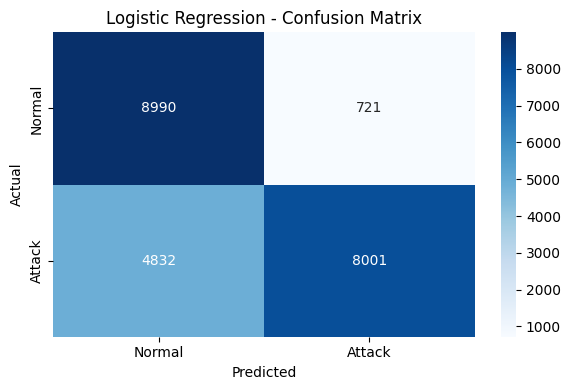

In [15]:
# Plot confusion matrix
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [16]:
#Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

end = time.time()
print(f"Training complete! Time taken: {round(end - start, 2)} seconds")

Training Random Forest...
Training complete! Time taken: 9.41 seconds


In [17]:
# Make predictions
rf_predictions = rf_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

#"Both models struggled with Recall on the test set because KDDTest+ was designed to be harder, containing rare attack types underrepresented in training. This reflects a real world challenge in cybersecurity — models trained on known attacks may miss novel ones."

Random Forest Results:
Accuracy:  0.7648
Precision: 0.9670
Recall:    0.6075
F1 Score:  0.7462


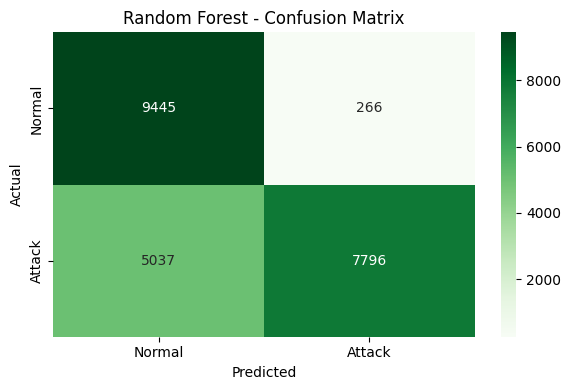

In [18]:
# Plot confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [19]:
#Neural Network 

from sklearn.neural_network import MLPClassifier

print("Training Neural Network...")
start = time.time()

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # 2 hidden layers
    activation='relu',             # ReLU activation function
    max_iter=100,                  # maximum iterations
    random_state=42,
    verbose=True                   # shows progress
)
nn_model.fit(X_train, y_train)

end = time.time()
print(f"\nTraining complete! Time taken: {round(end - start, 2)} seconds")

Training Neural Network...
Iteration 1, loss = 0.06137635
Iteration 2, loss = 0.02447093
Iteration 3, loss = 0.02072150
Iteration 4, loss = 0.01808543
Iteration 5, loss = 0.01673628
Iteration 6, loss = 0.01502237
Iteration 7, loss = 0.01462115
Iteration 8, loss = 0.01316575
Iteration 9, loss = 0.01245487
Iteration 10, loss = 0.01210345
Iteration 11, loss = 0.01096125
Iteration 12, loss = 0.01041557
Iteration 13, loss = 0.01056531
Iteration 14, loss = 0.00989878
Iteration 15, loss = 0.00936748
Iteration 16, loss = 0.00884169
Iteration 17, loss = 0.00855827
Iteration 18, loss = 0.00856084
Iteration 19, loss = 0.00846314
Iteration 20, loss = 0.00750944
Iteration 21, loss = 0.00739689
Iteration 22, loss = 0.00712333
Iteration 23, loss = 0.00697416
Iteration 24, loss = 0.00696541
Iteration 25, loss = 0.00696486
Iteration 26, loss = 0.00682148
Iteration 27, loss = 0.00701340
Iteration 28, loss = 0.00775994
Iteration 29, loss = 0.00686123
Iteration 30, loss = 0.00633369
Iteration 31, loss = 0

In [20]:
# Make predictions
nn_predictions = nn_model.predict(X_test)

# Calculate metrics
nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_precision = precision_score(y_test, nn_predictions)
nn_recall = recall_score(y_test, nn_predictions)
nn_f1 = f1_score(y_test, nn_predictions)

print("Neural Network Results:")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1 Score:  {nn_f1:.4f}")

Neural Network Results:
Accuracy:  0.8111
Precision: 0.9666
Recall:    0.6921
F1 Score:  0.8066


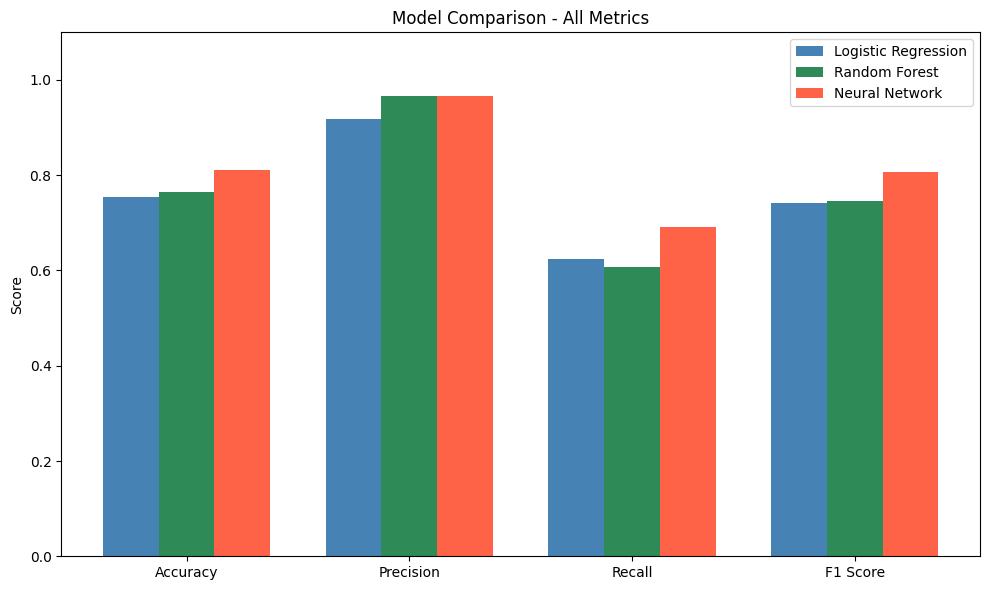

In [21]:
# Compare all models visually
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]
nn_scores = [nn_accuracy, nn_precision, nn_recall, nn_f1]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], lr_scores, width=width, label='Logistic Regression', color='steelblue')
plt.bar([i for i in x], rf_scores, width=width, label='Random Forest', color='seagreen')
plt.bar([i + width for i in x], nn_scores, width=width, label='Neural Network', color='tomato')

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.title('Model Comparison - All Metrics')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

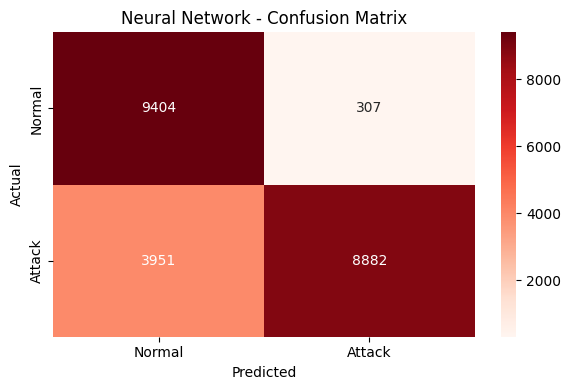

In [22]:
# Plot confusion matrix for Neural Network
cm_nn = confusion_matrix(y_test, nn_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Neural Network - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [23]:
# Final summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'Accuracy': [lr_accuracy, rf_accuracy, nn_accuracy],
    'Precision': [lr_precision, rf_precision, nn_precision],
    'Recall': [lr_recall, rf_recall, nn_recall],
    'F1 Score': [lr_f1, rf_f1, nn_f1]
})

results = results.set_index('Model')
results = results.round(4)
print(results)

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.7537     0.9173  0.6235    0.7424
Random Forest          0.7648     0.9670  0.6075    0.7462
Neural Network         0.8111     0.9666  0.6921    0.8066


In [ ]:
import numpy as np

# A sample network connection - you can change these values!
sample = pd.DataFrame({
    'duration': [0],
    'protocol_type': ['tcp'],
    'service': ['ftp'],
    'flag': ['SF'],
    'src_bytes': [832],
    'dst_bytes': [1168],
    'land': [0],
    'wrong_fragment': [0],
    'urgent': [0],
    'hot': [0],
    'num_failed_logins': [5],  # multiple failed logins!
    'logged_in': [0],          # never succeeded
    'num_compromised': [0],
    'root_shell': [0],
    'su_attempted': [0],
    'num_root': [0],
    'num_file_creations': [0],
    'num_shells': [0],
    'num_access_files': [0],
    'num_outbound_cmds': [0],
    'is_host_login': [0],
    'is_guest_login': [0],
    'count': [6],
    'srv_count': [6],
    'serror_rate': [0.0],
    'srv_serror_rate': [0.0],
    'rerror_rate': [0.0],
    'srv_rerror_rate': [0.0],
    'same_srv_rate': [1.0],
    'diff_srv_rate': [0.0],
    'srv_diff_host_rate': [0.0],
    'dst_host_count': [10],
    'dst_host_srv_count': [10],
    'dst_host_same_srv_rate': [1.0],
    'dst_host_diff_srv_rate': [0.0],
    'dst_host_same_src_port_rate': [0.1],
    'dst_host_srv_diff_host_rate': [0.0],
    'dst_host_serror_rate': [0.0],
    'dst_host_srv_serror_rate': [0.0],
    'dst_host_rerror_rate': [0.0],
    'dst_host_srv_rerror_rate': [0.0],
})

# Apply same preprocessing as training data
sample_encoded = pd.get_dummies(sample, columns=['protocol_type', 'service', 'flag'])
sample_encoded = sample_encoded.reindex(columns=train_columns, fill_value=0)
sample_scaled = scaler.transform(sample_encoded)

# Predict using all 3 models
lr_pred = lr_model.predict(sample_scaled)[0]
rf_pred = rf_model.predict(sample_scaled)[0]
nn_pred = nn_model.predict(sample_scaled)[0]

print("Results for your custom input:")
print(f"Logistic Regression: {'🚨 ATTACK' if lr_pred == 1 else '✅ NORMAL'}")
print(f"Random Forest:       {'🚨 ATTACK' if rf_pred == 1 else '✅ NORMAL'}")
print(f"Neural Network:      {'🚨 ATTACK' if nn_pred == 1 else '✅ NORMAL'}")

Results for your custom input:
Logistic Regression: 🚨 ATTACK
Random Forest:       ✅ NORMAL
Neural Network:      🚨 ATTACK


In [25]:
# Take real attack samples directly from the dataset
real_attack = X_test[y_test == 1][:5]  # 5 real attacks from test set
real_normal = X_test[y_test == 0][:5]  # 5 real normal from test set

print("Predictions on REAL attacks:")
print("LR:", lr_model.predict(real_attack))
print("RF:", rf_model.predict(real_attack))
print("NN:", nn_model.predict(real_attack))

print("\nPredictions on REAL normal traffic:")
print("LR:", lr_model.predict(real_normal))
print("RF:", rf_model.predict(real_normal))
print("NN:", nn_model.predict(real_normal))

Predictions on REAL attacks:
LR: [1 1 1 0 0]
RF: [1 1 1 0 0]
NN: [1 1 1 0 0]

Predictions on REAL normal traffic:
LR: [0 0 0 0 0]
RF: [0 0 0 0 0]
NN: [0 0 0 0 0]
